In [1]:
import sys, os
import tkinter as tk
import time
from matplotlib import pyplot as plt
import cv2
import queue
import numpy as np
from tdmclient import ClientAsync, aw

# Compute absolute path to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), "."))
src_path = os.path.join(project_root, "src")

# Add src/ to sys.path
if src_path not in sys.path:
    print(f"Adding {src_path} to PYTHONPATH")
    sys.path.insert(0, src_path)

ImportError: DLL load failed while importing cv2: The specified module could not be found.

In [10]:
from src.gui.init_vision_wizard import InitVisionWizard
from src.utils.camera_utils import find_available_camera
from src.computer_vision.camera_capture_thread import CameraCaptureThread
from src.computer_vision.computer_vision import ComputerVisionCore
from src.computer_vision.vision_params_manager import VisionParamsManager
from src.global_navigation.global_nav2 import GlobalNavigator
from src.computer_vision.vision import Vision
from src.pose_estimation.extended_kalman_filter import ExtendedKalmanFilter
from src.pose_estimation.differential_drive_system import DifferentialDriveSystem
from src.local_navigation.navigation_control import *

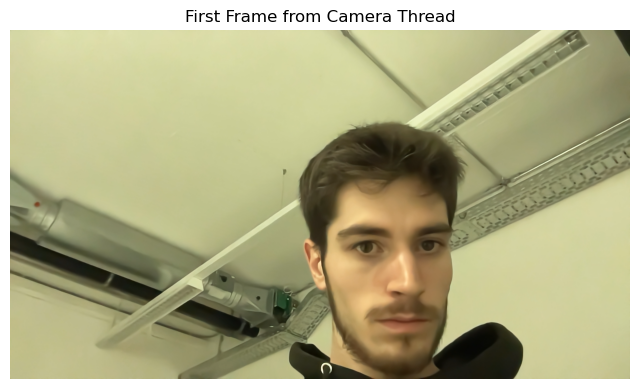

In [6]:
# -------------------------
# Initialize Vision Wizard
# -------------------------

# Function to handle initialization on button click
def on_initialize(self):
    """Start computer vision initialization."""
    # 1. Capture ONE frame directly from the camera
    _, cap = find_available_camera()

    # Warm-up: try to grab a valid frame within 2 seconds
    start = time.time()
    frame = None
    while time.time() - start < 2.0:
        ok, f = cap.read()
        if ok and f is not None:
            # reject dark/black frames
            if f.mean() > 5:    # more robust than sum != 0
                frame = f
                break
        time.sleep(0.03)

    cap.release()

    if frame is None:
        raise RuntimeError("Failed to capture a valid frame from the camera.")

    # 3. Pass the captured FRAME to the wizard
    wizard = InitVisionWizard(self, frame)

    wizard.grab_set()           # modal window
    self.wait_window(wizard)    # wait for wizard to finish

    # 4. After the wizard is closed, you can access the results
    plt.figure(figsize=(8,6))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("First Frame from Camera Thread")
    plt.axis("off")
    plt.show()

# Launch a temporary Tkinter window to hold initialization button
root = tk.Tk()
root.title("Initialization window")

# Button to start initialization
btn = tk.Button(root, text="Initialize Vision", command=lambda: on_initialize(root))
btn.pack()

root.mainloop()

Waiting for first frame...
Received first frame, shape: (1080, 1920, 3)
Initial robot state: True (1023, 725) None
Initial goal state: True (354, 534)


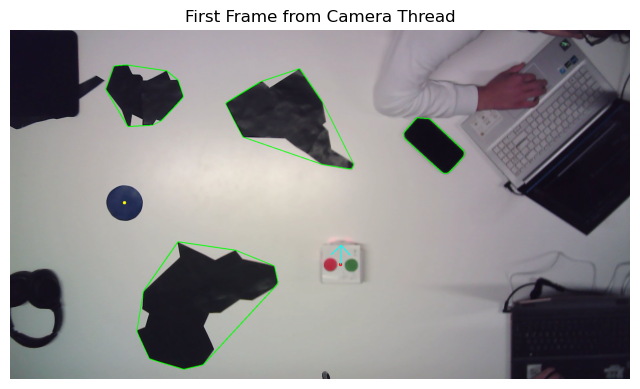

In [4]:
# -------------------------
# Capture first frame
# -------------------------

# 1. Create a queue for receiving camera frames + robot pose
data_queue = queue.Queue(maxsize=1)

# 2. Start the camera capture thread
camera_thread = CameraCaptureThread(queue=data_queue, device_index=0)
camera_thread.start()

# 3. Wait for the first data packet
print("Waiting for first frame...")
packet = None
while packet is None:
    try:
        packet = data_queue.get(timeout=1.0)
    except queue.Empty:
        print("Still waiting...")

frame = packet["frame"]
detections = packet["detections"]

robot = detections["robot"]
goal = detections["goal"]
obstacles = detections["obstacles"]

print("Received first frame, shape:", frame.shape)
print("Initial robot state:", robot["found"], robot.get("center", None), robot.get("orientation_deg", None))
print("Initial goal state:", goal["found"], goal.get("center", None))

camera_thread.stop()
camera_thread.join()

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title("First Frame from Camera Thread")
plt.axis("off")
plt.show()

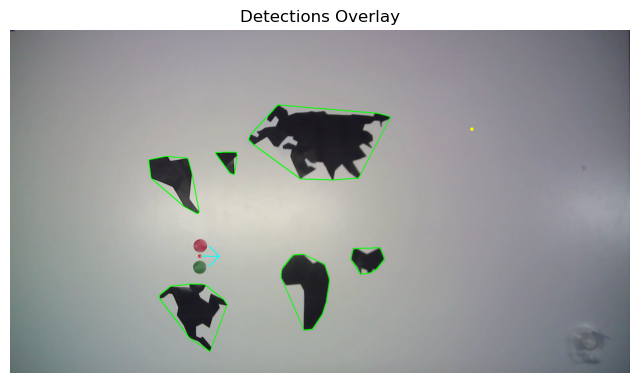

In [ ]:
# --------------
# DEBUG cell
# --------------

params = VisionParamsManager()
params.load()

# Load an image/frame for path planning tests
frame = cv2.imread("vision_live_output_pour_mehdi.jpg")

overlay_frame = frame.copy()

# Vision wrapper handles smoothing internally
robot = ComputerVisionCore.detect_robot(frame, params.color_params)
goal = {"found": True, "center": (1400, 300)}  # Example goal data
obstacles = ComputerVisionCore.detect_obstacles(frame, params.color_params,params.canny_params, params.poly_params)

# Overlay static obstacles
for poly in obstacles:
    pts = np.array(poly.exterior.coords, np.int32)
    cv2.polylines(overlay_frame, [pts], True, (0, 255, 0), 2)

# Overlay goal
if goal and goal["found"] and goal["center"] is not None:
    cv2.circle(overlay_frame, goal["center"], 5, (0, 255, 255), -1)

# Overlay robot
if robot and robot["found"]:
    center = robot["center"]
    theta = robot["theta"]
    arrow_length = 60
    dx = int(arrow_length * np.cos(theta))
    dy = int(arrow_length * np.sin(theta))
    cv2.circle(overlay_frame, center, 5, (0, 0, 255), -1)
    cv2.arrowedLine(overlay_frame, center, (center[0]+dx, center[1]+dy), (255, 255, 0), 2, tipLength=0.7)

# Aggregate all detection data
detection_data = {
    "robot": robot,
    "goal": goal,
    "obstacles": obstacles
}

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(overlay_frame, cv2.COLOR_BGR2RGB))
plt.title("Detections Overlay")
plt.axis("off")
plt.show()

100%|██████████| 4/4 [00:00<00:00, 278.44it/s]

Global path: [(1023.0, 725.0), (876.6003200467948, 664.4142309840178), (719.6495874445362, 601.1063724553757), (354.0, 534.0)]


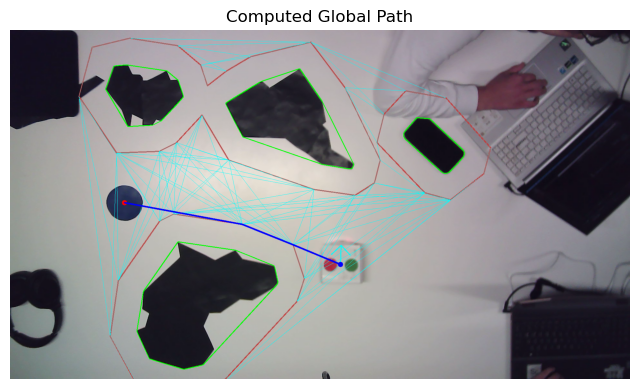

In [5]:
# Check that everything is valid
path = None
if robot["found"] and goal["found"]:
      robot_center = robot["center"]
      goal_center = goal["center"]

      # Convert obstacles from Shapely Polygons to lists of tuples
      obstacle_list = [list(p.exterior.coords)[:-1] for p in obstacles]

      # Compute global path
      path, path_img = GlobalNavigator.plan_path(
            obstacles=obstacle_list,
            start=robot_center,
            goal=goal_center,
            robot_radius_px=ComputerVisionCore.mm_to_px(ComputerVisionCore.ROBOT_RADIUS_MM),
            img_width=frame.shape[1],
            img_height=frame.shape[0],
            debug_img=frame.copy()
      )

      # path is a list of (x, y) tuples
      print("Global path:", path)

      # Optionally visualize
      plt.figure(figsize=(8,6))
      plt.imshow(cv2.cvtColor(path_img, cv2.COLOR_BGR2RGB))
      plt.title("Computed Global Path")
      plt.axis("off")
      plt.show()

In [6]:
# 1.6 EKF + Thymio client are created elsewhere, e.g.
# ekf = YourEKF(...)
# thymio = YourThymioClient(...)
lambda_ = 0.39735099337748336  # conversion factor
d = 93.5         # distance between wheels
# Default value for now
Q = np.diag([0.03, 0.03, 0.03])
R = np.diag([0.01, 0.01, 0.01])
dt = 0.1  # time step

system = DifferentialDriveSystem(dt, lambda_, d, Q, R)
    
# Initial state and covariance
mu0 = np.array([0, 0, 0])
Sigma0 = 1000 * np.eye(3)

ekf = ExtendedKalmanFilter(
    mu0, Sigma0,
    system
)

# To store estimates
x_est = []
P_est = []

x_est.append(mu0)

In [7]:
client = ClientAsync()
node = await client.wait_for_node()
await node.lock()
await node.wait_for_variables({"prox.horizontal"})

def motors(l_speed=0, r_speed=0):
    return {
        "motor.left.target": [int(l_speed)],
        "motor.right.target": [int(r_speed)],
    }



In [ ]:
#await node.set_variables(motors(50,50))
await node.set_variables(motors(0,0))

In [ ]:
async def fsm():
    camera_thread = CameraCaptureThread(queue=data_queue, device_index=0)
    camera_thread.start()

    print("Starting path following with obstacle avoidance...")
    for step in range(200):
        try:
            packet = data_queue.get(timeout=1.0)
        except queue.Empty:
            print("Still waiting...")
            continue
        
        frame = packet["frame"]
        detections = packet["detections"]

        robot_state = detections["robot"]
        goal_state = detections["goal"]
        obstacles = detections["obstacles"]

        # --- get sensors from Thymio ---
        sensor_vals = list(node.v.prox.horizontal)
        
        speed_left  = node.v.motor.left.speed
        speed_right = node.v.motor.right.speed
        u = np.array([speed_left, speed_right])
        # pose from ekf 
        #pose, cov = ekf.predict(u)

        if robot_state["found"]:
            x, y = robot_state["center"]
            theta = robot_state["theta"]
            print("Vision: x:", x, "y:", y, "theta:", theta)
            z = np.array([x, y, theta])
            #pose, cov = ekf.update(z)
            pose=z
        else:
            pose=x_est[-1] if x_est else mu0


        x_est.append(pose)
        #P_est.append(cov)

        # --- update local grid ---
        grid.update_from_sensor_vals(sensor_vals)
        print("Pose:", pose)

        dense_path = densify_path(path, 10)

        # --- compute virtual goal ---
        virt_world, LA_world, F_att, F_rep = navigator.compute_virtual_goal(
            pose, dense_path, sensor_vals=sensor_vals #iciiii
        )
        print("LQA (world):", LA_world)

        print("Virtual goal (world):", virt_world,"\n")
        if virt_world is None:
            break

        # --- controller: pose -> motors ---
        uL, uR, info = g2g.compute_motor_commands(pose, virt_world)

        await node.set_variables({
            "motor.left.target":  [uL],
            "motor.right.target": [uR],
        })

        
        # small sleep
        await client.sleep(dt)

    # stop motors at the end
    await node.set_variables({
        "motor.left.target":  [0],
        "motor.right.target": [0],
    })
    await node.unlock()

In [11]:
await fsm()

Starting path following with obstacle avoidance...
Vision: x: 1022 y: 725 theta: -1.5405025668761214
Pose: [1022.          725.           -1.54050257]


NameError: name 'dense_path' is not defined

In [ ]:
await node.set_variables(motors(0,0))

In [10]:
await node.unlock()

{'error_code': 2}